# 0. Import library

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # 물리적 2번 GPU만 보이게 설정

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")
# 이제 torch.cuda.get_device_name(0)을 하면 물리적 2번 GPU의 이름이 나옵니다.

Current device: cuda


In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


# 1-1. Import Data 

In [3]:
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')
print(df_all.shape)
print(df_all.columns)

nan_rows = df_all[df_all.isna().any(axis=1)]

df_all = df_all.dropna()

loc_X = df_all["X"].to_numpy().reshape(-1,1)
loc_Y = df_all["Y"].to_numpy().reshape(-1,1)
loc_Z = df_all["Z"].to_numpy().reshape(-1,1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
# dist_Z = df_all["Dist_to_nearest_Z"].to_numpy()[::2].reshape(-1,1)
scan_spd = df_all["scanning_speed"].to_numpy().reshape(-1,1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1,1)
laser_on_off = df_all["laser_power_number"].to_numpy().reshape(-1,1)

# apply moving average for mp temp
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1,1)

# apply moving average for mp depth
mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw,4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1,1)       


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


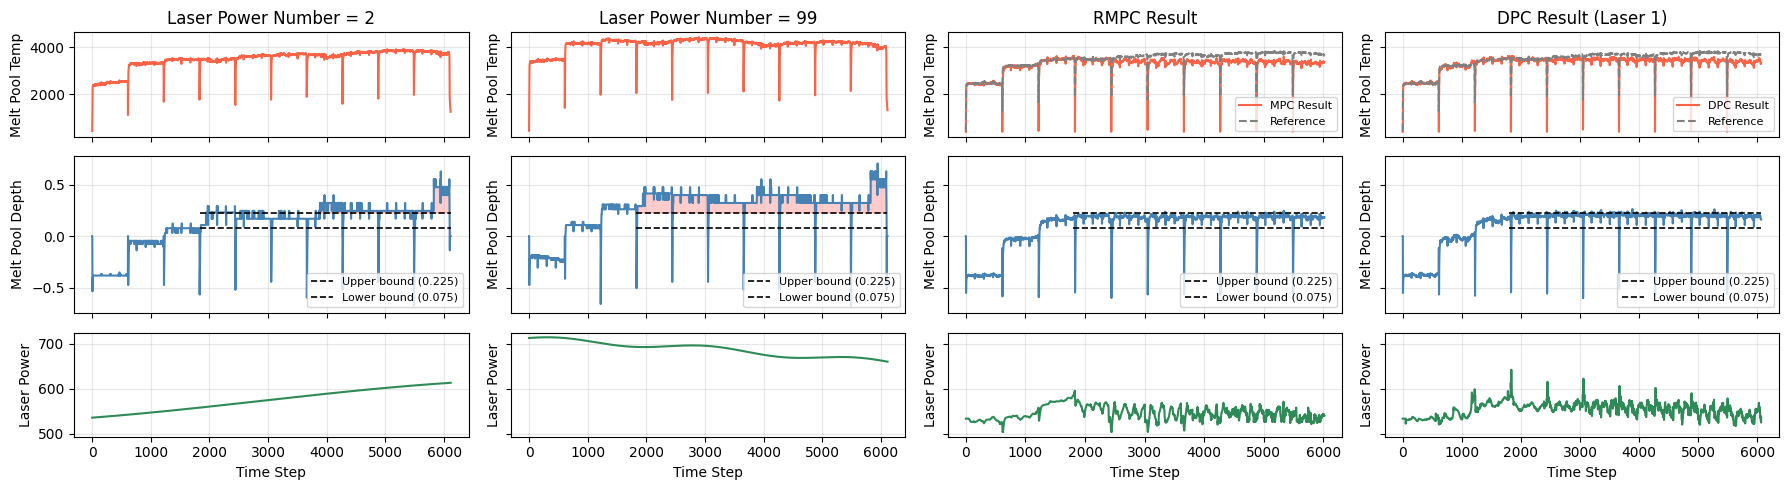

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

lw = 1.5
cutoff = 201-20
las_nums = [2, 99]
dpc_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation/policy_roll_epoch0199.pth_clamped(1)"
mpc_csv = '/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv'
#mpc_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_MPC_w_depth_control_0925.csv"

# RMPC / DPC 데이터 로드
df_rmpc = pd.read_csv(mpc_csv)
df_x   = pd.read_csv(os.path.join(dpc_dir, 'x_outputs_laser_1.csv'))
df_u   = pd.read_csv(os.path.join(dpc_dir, 'u_outputs_laser_1.csv'))
df_ref = pd.read_csv(os.path.join(dpc_dir, 'ref_laser_1.csv'))

# RMPC
df_rmpc = df_rmpc.iloc[:-cutoff].reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(18, 5), sharex=False, sharey='row',
                         gridspec_kw={'height_ratios': [2, 3, 2]})

# ── 기존 두 컬럼 (laser_power_number = 2, 99) ──
for col, las_num in enumerate(las_nums):

    df_plot = df_all[df_all["laser_power_number"] == las_num].reset_index(drop=True)
    df_plot = df_plot.iloc[::2].reset_index(drop=True)
    #df_plot = df_plot.iloc[:-95].reset_index(drop=True)
    df_plot = df_plot.iloc[:-(cutoff // 2)].reset_index(drop=True)
    x_actual = df_plot.index * 2

    mask_z = df_plot["Z"] > 2.5

    axes[0, col].plot(x_actual, df_plot["melt_pool_temperature"], color='tomato', linewidth=lw)
    axes[0, col].set_ylabel("Melt Pool Temp")
    axes[0, col].set_title(f"Laser Power Number = {las_num}")
    axes[0, col].grid(True, alpha=0.3)
    axes[0, col].tick_params(labelbottom=False)

    ax = axes[1, col]
    ax.plot(x_actual, df_plot["melt_pool_depth"], color='steelblue', linewidth=lw)
    ax.set_ylabel("Melt Pool Depth")
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelbottom=False)

    idx = np.where(mask_z)[0]
    if len(idx) > 0:
        x_min_z, x_max_z = x_actual[idx[0]], x_actual[idx[-1]]
        depth_vals = df_plot["melt_pool_depth"]

        ax.hlines(0.225, x_min_z, x_max_z, colors='black', linestyles='--', linewidth=1.2, label='Upper bound (0.225)')
        ax.hlines(0.075, x_min_z, x_max_z, colors='black', linestyles='--', linewidth=1.2, label='Lower bound (0.075)')
        ax.fill_between(x_actual, depth_vals, 0.075,
                        where=(mask_z & (depth_vals < 0.075)),
                        color='red', alpha=0.2)
        ax.fill_between(x_actual, depth_vals, 0.225,
                        where=(mask_z & (depth_vals > 0.225)),
                        color='red', alpha=0.2)
        ax.legend(loc='lower right', fontsize=8)

    axes[2, col].plot(x_actual, df_plot["Laser_power"], color='seagreen', linewidth=lw)
    axes[2, col].set_ylabel("Laser Power")
    axes[2, col].set_xlabel("Time Step")
    axes[2, col].grid(True, alpha=0.3)

# ── RMPC 결과 (col=2) ──
col = 2
x_rmpc = df_rmpc.index

axes[0, col].plot(x_rmpc, df_rmpc["gamma_result_temp"], color='tomato', linewidth=lw, label='MPC Result')
axes[0, col].plot(x_rmpc, df_rmpc["ref"],               color='gray',   linewidth=lw, linestyle='--', label='Reference')
axes[0, col].set_ylabel("Melt Pool Temp")
axes[0, col].set_title("RMPC Result")
axes[0, col].grid(True, alpha=0.3)
axes[0, col].tick_params(labelbottom=False)
axes[0, col].legend(loc='lower right', fontsize=8)

ax = axes[1, col]
depth_vals_r = df_rmpc["gamma_result_depth"]
ax.plot(x_rmpc, depth_vals_r, color='steelblue', linewidth=lw)
ax.set_ylabel("Melt Pool Depth")
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False)

mask_r = x_rmpc >= 1800
ax.hlines(0.225, 1800, x_rmpc[-1], colors='black', linestyles='--', linewidth=1.2, label='Upper bound (0.225)')
ax.hlines(0.075, 1800, x_rmpc[-1], colors='black', linestyles='--', linewidth=1.2, label='Lower bound (0.075)')
ax.fill_between(x_rmpc, depth_vals_r, 0.075,
                where=(mask_r & (depth_vals_r < 0.075)),
                color='red', alpha=0.2)
ax.fill_between(x_rmpc, depth_vals_r, 0.225,
                where=(mask_r & (depth_vals_r > 0.225)),
                color='red', alpha=0.2)
ax.legend(loc='lower right', fontsize=8)

axes[2, col].plot(x_rmpc, df_rmpc["LP"], color='seagreen', linewidth=lw)
axes[2, col].set_ylabel("Laser Power")
axes[2, col].set_xlabel("Time Step")
axes[2, col].grid(True, alpha=0.3)

# ── DPC 결과 (col=3) ──
col = 3
temp  = df_x['0'].values
depth = df_x['1'].values
u     = df_u['0'].values
ref   = df_ref['0'].values

N = min(len(temp), len(u), len(ref))- cutoff 
t = np.arange(N)


axes[0, col].plot(t, temp[:N],  color='tomato', linewidth=lw, label='DPC Result')
axes[0, col].plot(t, ref[:N],   color='gray',   linewidth=lw, linestyle='--', label='Reference')
axes[0, col].set_ylabel("Melt Pool Temp")
axes[0, col].set_title("DPC Result (Laser 1)")
axes[0, col].grid(True, alpha=0.3)
axes[0, col].tick_params(labelbottom=False)
axes[0, col].legend(loc='lower right', fontsize=8)

ax = axes[1, col]
ax.plot(t, depth[:N], color='steelblue', linewidth=lw)
ax.set_ylabel("Melt Pool Depth")
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False)

mask_c = t >= 1800
if mask_c.any():
    ax.hlines(0.225, 1800, t[-1], colors='black', linestyles='--', linewidth=1.2, label='Upper bound (0.225)')
    ax.hlines(0.075, 1800, t[-1], colors='black', linestyles='--', linewidth=1.2, label='Lower bound (0.075)')
    ax.fill_between(t, depth[:N], 0.075,
                    where=(mask_c & (depth[:N] < 0.075)),
                    color='red', alpha=0.2)
    ax.fill_between(t, depth[:N], 0.225,
                    where=(mask_c & (depth[:N] > 0.225)),
                    color='red', alpha=0.2)
    ax.legend(loc='lower right', fontsize=8)

axes[2, col].plot(t, u[:N], color='seagreen', linewidth=lw)
axes[2, col].set_ylabel("Laser Power")
axes[2, col].set_xlabel("Time Step")
axes[2, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

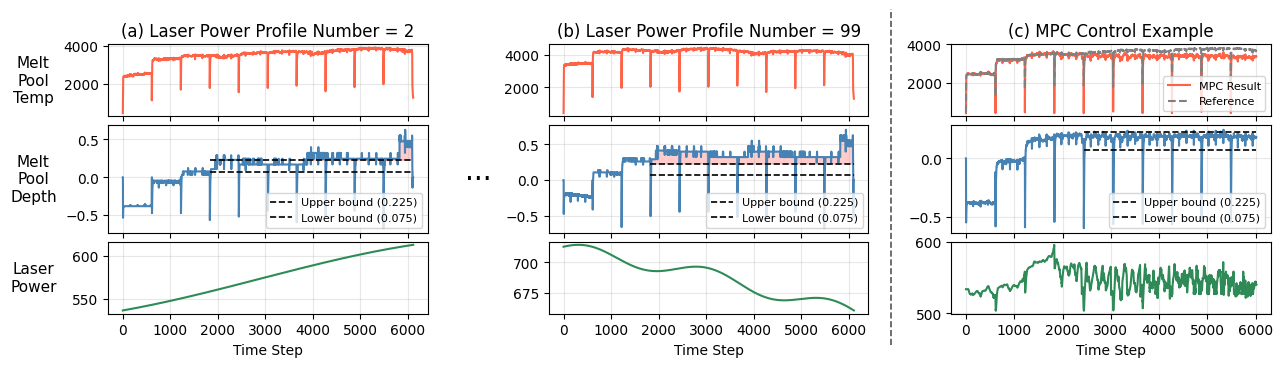

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

lw = 1.5
cutoff = 201 - 20
las_nums = [2, 99]

fig = plt.figure(figsize=(15, 3.5))

gs = gridspec.GridSpec(3, 5, figure=fig,
                       width_ratios=[10, -2, -2, 10, 10],
                       height_ratios=[2, 3, 2],
                       hspace=0.1, wspace=0.5)

axes_left  = [fig.add_subplot(gs[r, 0]) for r in range(3)]
axes_right = [fig.add_subplot(gs[r, 3]) for r in range(3)]
axes_rmpc  = [fig.add_subplot(gs[r, 4]) for r in range(3)]
ax_mid     = fig.add_subplot(gs[:, 1])


# 중간 ... 표시
ax_mid.axis('off')
ax_mid.text(0.5, 0.5, '···', ha='center', va='center',
            fontsize=20, transform=ax_mid.transAxes)

all_axes = [axes_left, axes_right]

for col_axes, las_num in zip(all_axes, las_nums):

    df_plot = df_all[df_all["laser_power_number"] == las_num].reset_index(drop=True)
    df_plot = df_plot.iloc[::2].reset_index(drop=True)
    df_plot = df_plot.iloc[:-(cutoff // 2)].reset_index(drop=True)
    x_actual = df_plot.index * 2

    mask_z = df_plot["Z"] > 2.5

    col_axes[0].plot(x_actual, df_plot["melt_pool_temperature"], color='tomato', linewidth=lw)
    col_axes[0].set_title(f"Laser Power Number = {las_num}")
    col_axes[0].grid(True, alpha=0.3)
    col_axes[0].tick_params(labelbottom=False)

    ax = col_axes[1]
    ax.plot(x_actual, df_plot["melt_pool_depth"], color='steelblue', linewidth=lw)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelbottom=False)

    idx = np.where(mask_z)[0]
    if len(idx) > 0:
        x_min_z, x_max_z = x_actual[idx[0]], x_actual[idx[-1]]
        depth_vals = df_plot["melt_pool_depth"]

        ax.hlines(0.225, x_min_z, x_max_z, colors='black', linestyles='--', linewidth=1.2, label='Upper bound (0.225)')
        ax.hlines(0.075, x_min_z, x_max_z, colors='black', linestyles='--', linewidth=1.2, label='Lower bound (0.075)')
        ax.fill_between(x_actual, depth_vals, 0.075,
                        where=(mask_z & (depth_vals < 0.075)),
                        color='red', alpha=0.2)
        ax.fill_between(x_actual, depth_vals, 0.225,
                        where=(mask_z & (depth_vals > 0.225)),
                        color='red', alpha=0.2)
        ax.legend(loc='lower right', fontsize=8)

    col_axes[2].plot(x_actual, df_plot["Laser_power"], color='seagreen', linewidth=lw)
    col_axes[2].set_xlabel("Time Step")
    col_axes[2].grid(True, alpha=0.3)

# ylabel 맨 좌측만
axes_left[0].set_ylabel("Melt Pool Temp")
axes_left[1].set_ylabel("Melt Pool Depth")
axes_left[2].set_ylabel("Laser Power")

# ── RMPC (col=4) ──
x_rmpc = df_rmpc.index

axes_rmpc[0].plot(x_rmpc, df_rmpc["gamma_result_temp"], color='tomato', linewidth=lw, label='MPC Result')
axes_rmpc[0].plot(x_rmpc, df_rmpc["ref"],               color='gray',   linewidth=lw, linestyle='--', label='Reference')
axes_rmpc[0].set_title("RMPC Result")
axes_rmpc[0].grid(True, alpha=0.3)
axes_rmpc[0].tick_params(labelbottom=False)
axes_rmpc[0].legend(loc='lower right', fontsize=8)

ax = axes_rmpc[1]
depth_vals_r = df_rmpc["gamma_result_depth"]
ax.plot(x_rmpc, depth_vals_r, color='steelblue', linewidth=lw)
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False)

mask_r = x_rmpc >= 2440
ax.hlines(0.225, 2440, x_rmpc[-1], colors='black', linestyles='--', linewidth=1.2, label='Upper bound (0.225)')
ax.hlines(0.075, 2440, x_rmpc[-1], colors='black', linestyles='--', linewidth=1.2, label='Lower bound (0.075)')
ax.fill_between(x_rmpc, depth_vals_r, 0.075,
                where=(mask_r & (depth_vals_r < 0.075)), color='red', alpha=0.2)
ax.fill_between(x_rmpc, depth_vals_r, 0.225,
                where=(mask_r & (depth_vals_r > 0.225)), color='red', alpha=0.2)
ax.legend(loc='lower right', fontsize=8)

axes_rmpc[2].plot(x_rmpc, df_rmpc["LP"], color='seagreen', linewidth=lw)
axes_rmpc[2].set_xlabel("Time Step")
axes_rmpc[2].grid(True, alpha=0.3)

pos = axes_right[0].get_position()
x_line = pos.x1 + 0.015  # 0.02 만큼 우측으로 떨어뜨리기

from matplotlib.lines import Line2D
line = Line2D(
    [x_line, x_line], [0.02, 0.98],
    transform=fig.transFigure,
    color='#555555',        # 🔥 짙은 회색
    linewidth=1.2,          # 🔥 조금 더 두껍게
    linestyle='--'          # 🔥 점선
)
fig.add_artist(line)

plt.tight_layout()


# axes_left ylabel 제거
axes_left[0].set_ylabel("")
axes_left[1].set_ylabel("")
axes_left[2].set_ylabel("")

# figure 좌표계에서 좌측 정렬로 직접 배치
pos0 = axes_left[0].get_position()
pos1 = axes_left[1].get_position()
pos2 = axes_left[2].get_position()
x_label = pos0.x0 - 0.05  # 좌측으로 얼마나 떨어질지

fig.text(x_label, (pos0.y0 + pos0.y1) / 2, "Melt\nPool\nTemp",
         ha='center', va='center', rotation=0, fontsize=11)
fig.text(x_label, (pos1.y0 + pos1.y1) / 2, "Melt\nPool\nDepth",
         ha='center', va='center', rotation=0, fontsize=11)
fig.text(x_label, (pos2.y0 + pos2.y1) / 2, "Laser\nPower",
         ha='center', va='center', rotation=0, fontsize=11)

for ax, title, label in zip(
    [axes_left[0], axes_right[0], axes_rmpc[0]],
    [f"Laser Power Profile Number = 2", f"Laser Power Profile Number = 99", "MPC Control Example"],
    ['(a)', '(b)', '(c)']
):
    ax.set_title(f"{label} {title}")
    
plt.show()